In [20]:
#lab test 1 (ITW)
#given microsoft stock data, to store the 50 records in the form of a list of tuples > each tuple contains date, open, high, low close and volume values
#then convert the same data into dictionary in which the key represents the data and the value repre the corresp stock price details for that record. create a set to store all the unique trading years or months present in the data set and write a program to extract and display only those tuples
#the closing price is greater specific threshhold (close > 300)
#specific threshold given as -> **close > 300**
import pandas as pd

df = pd.read_csv("/content/Microsoft_Stock.csv")

df1 = df.head(50)
#defining the stock list []


stock_list = []
stock_dict = {}
for index, row in df1.iterrows():
    stock_list.append((
        row['Date'],
        row['Open'],
        row['High'],
        row['Low'],
        row['Close'],
        row['Volume']
    ))

print("List of Tuples (First 50 Records):")
print(stock_list)

#here we are defining dictionaries
for record in stock_list:
    date = record[0]
    stock_dict[date] = record[1:]

print("\nDictionary Format:")
print(stock_dict)
# Step creating the set of unique trading years
years_set = set()

for record in stock_list:
    date = record[0]
    year = date.split('-')[0]   #proper format for the dates for the trading yrs
    years_set.add(year)

print("\nUnique Trading Years:")
print(years_set)

# for the final specified threshold of "Close > 300"

threshold = 300

filtered_records = []

for record in stock_list:
    close_price = record[4]
    if close_price > threshold:
        filtered_records.append(record)

print("\nRecords where Close > 300:") #there is no record for where close > 300
print(filtered_records)




List of Tuples (First 50 Records):
[('4/1/2015 16:00:00', 40.6, 40.76, 40.31, 40.72, 36865322), ('4/2/2015 16:00:00', 40.66, 40.74, 40.12, 40.29, 37487476), ('4/6/2015 16:00:00', 40.34, 41.78, 40.18, 41.55, 39223692), ('4/7/2015 16:00:00', 41.61, 41.91, 41.31, 41.53, 28809375), ('4/8/2015 16:00:00', 41.48, 41.69, 41.04, 41.42, 24753438), ('4/9/2015 16:00:00', 41.25, 41.62, 41.25, 41.48, 25723861), ('4/10/2015 16:00:00', 41.63, 41.95, 41.41, 41.72, 28022002), ('4/13/2015 16:00:00', 41.4, 42.06, 41.39, 41.76, 30276692), ('4/14/2015 16:00:00', 41.8, 42.03, 41.39, 41.65, 24244382), ('4/15/2015 16:00:00', 41.76, 42.46, 41.68, 42.26, 27343581), ('4/16/2015 16:00:00', 41.95, 42.34, 41.82, 42.16, 22509652), ('4/17/2015 16:00:00', 41.67, 41.74, 41.16, 41.62, 42387608), ('4/20/2015 16:00:00', 41.73, 43.17, 41.68, 42.91, 46057733), ('4/21/2015 16:00:00', 43.0, 43.15, 42.53, 42.64, 26013844), ('4/22/2015 16:00:00', 42.67, 43.13, 42.55, 42.99, 25064273), ('4/23/2015 16:00:00', 42.85, 43.61, 42.8, 4

In [28]:
# for the microsoft stock data file into a pandas dataframe and perform
#detailed data analysis
#to display the summary stats such as open, close, high, low and volume to understand their overall distribution
#determine the month or year with the highest avg closing price and identify the specific date on which the maximum closing price was recorded
#group the dataset month wise (or year wise) and compute the mean closing price for each period to compare stock performance over time
#using numpy functions calculate the mean closing price median trading volume, standard deviation of daily returns and variance of high prices.
#finally identify the days on which the closing price is more than
#one standard deviation above the overall mean closing price

import numpy
import pandas as pd

df = pd.read_csv("/content/Microsoft_Stock.csv")

df['Date'] = pd.to_datetime(df['Date'])

#Detailed summary of the whole data :
df.set_index('Date', inplace=True)
print("\nSummary Stats:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())
#Yearly avg close
yearly_avg_close = df['Close'].resample('Y').mean()
max_year = yearly_avg_close.idxmax()

print("\nYear with Highest Average Closing Price:", max_year.year)
#with the highest avg

max_close_date = df['Close'].idxmax()
max_close_value = df['Close'].max()

print("Date with Maximum Closing Price:", max_close_date.date())
print("Maximum Closing Price:", max_close_value)

monthly_avg_close = df['Close'].resample('M').mean()

print("\nMonth-wise Mean Closing Price:")
print(monthly_avg_close)

df['Daily_Return'] = df['Close'].pct_change()

mean_close = np.mean(df['Close'])
median_volume = np.median(df['Volume'])
std_daily_returns = np.std(df['Daily_Return'].dropna())
variance_high = np.var(df['High'])

#using the numpy fnc for the calculation part :

print("\nNumPy Calculations:")
print("Mean Closing Price:", mean_close) #mean closing
print("Median Trading Volume:", median_volume) #median volume
print("Standard Deviation of Daily Returns:", std_daily_returns) #Standard dev
print("Variance of High Prices:", variance_high) #variance of the high prices
#The days on which the closing price is more than one standard deviation above
# the overall mean closing price


print("\n The day closing price is more than one standard d:" ,)







Summary Stats:
              Open         High          Low        Close        Volume
count  1511.000000  1511.000000  1511.000000  1511.000000  1.511000e+03
mean    107.385976   108.437472   106.294533   107.422091  3.019863e+07
std      56.691333    57.382276    55.977155    56.702299  1.425266e+07
min      40.340000    40.740000    39.720000    40.290000  1.016120e+05
25%      57.860000    58.060000    57.420000    57.855000  2.136213e+07
50%      93.990000    95.100000    92.920000    93.860000  2.662962e+07
75%     139.440000   140.325000   137.825000   138.965000  3.431962e+07
max     245.030000   246.130000   242.920000   244.990000  1.352271e+08

Year with Highest Average Closing Price: 2021
Date with Maximum Closing Price: 2021-02-12
Maximum Closing Price: 244.99

Month-wise Mean Closing Price:
Date
2015-04-30     43.466667
2015-05-31     47.530000
2015-06-30     45.964091
2015-07-31     45.611818
2015-08-31     45.506667
                 ...    
2020-11-30    214.139000
202

/tmp/ipython-input-2365409737.py:22: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg_close = df['Close'].resample('Y').mean()
/tmp/ipython-input-2365409737.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_close = df['Close'].resample('M').mean()


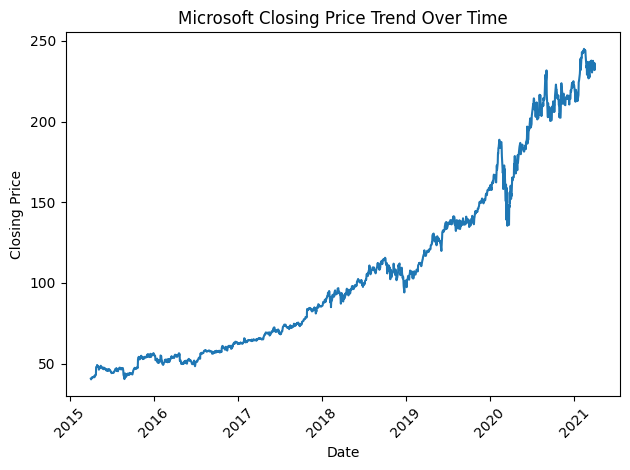

/tmp/ipython-input-4260466392.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Close'].resample('M').mean()


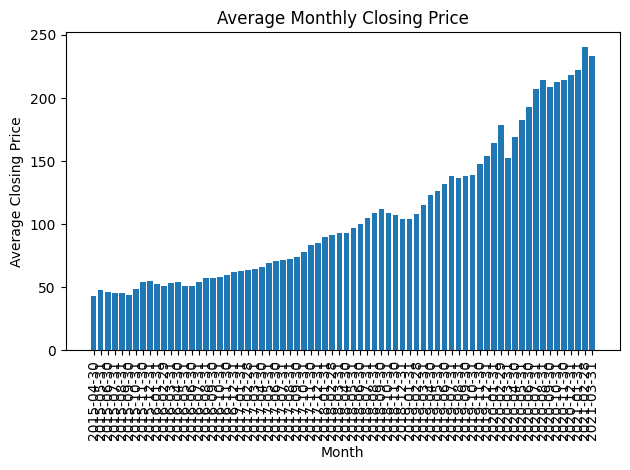

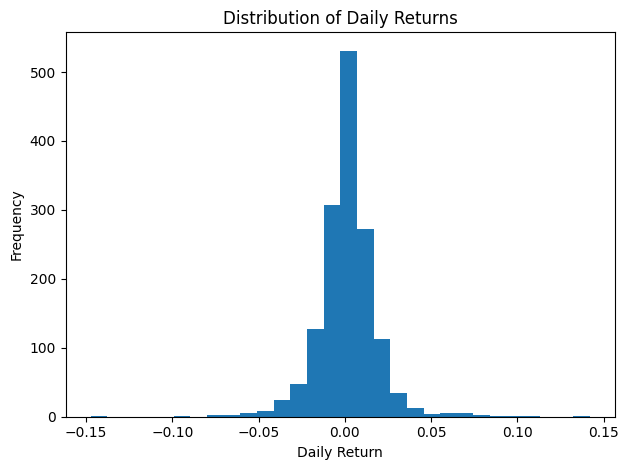

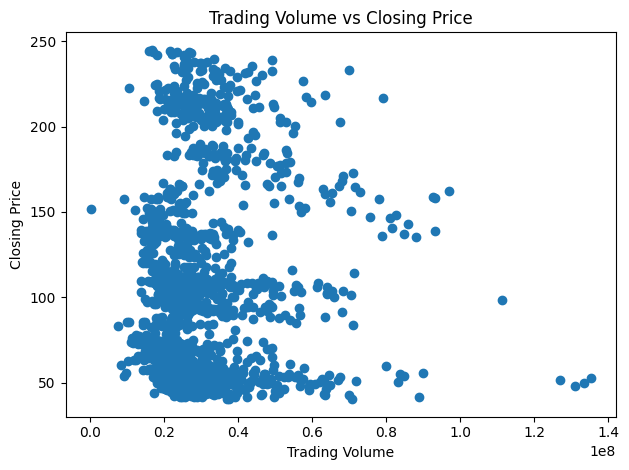

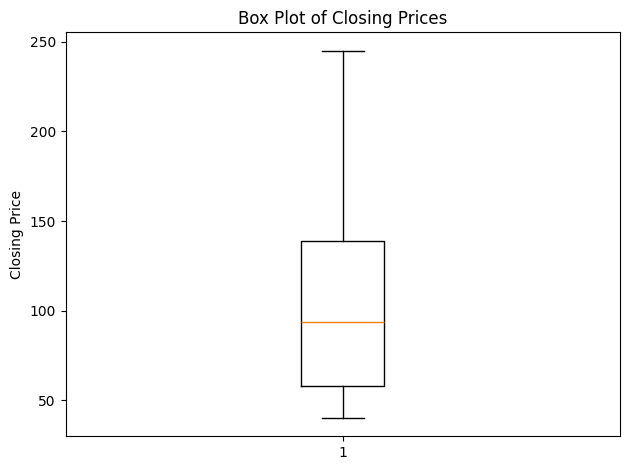

In [31]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Microsoft_Stock.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Calculate Daily Returns
df['Daily_Return'] = df['Close'].pct_change()


plt.figure()
plt.plot(df.index, df['Close'])
plt.title("Microsoft Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


monthly_avg = df['Close'].resample('M').mean()

plt.figure()
plt.bar(monthly_avg.index.astype(str), monthly_avg.values)
plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


plt.figure()
plt.hist(df['Daily_Return'].dropna(), bins=30)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure()
plt.scatter(df['Volume'], df['Close'])
plt.title("Trading Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()


plt.figure()
plt.boxplot(df['Close'])
plt.title("Box Plot of Closing Prices")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()


NameError: name 'handles' is not defined

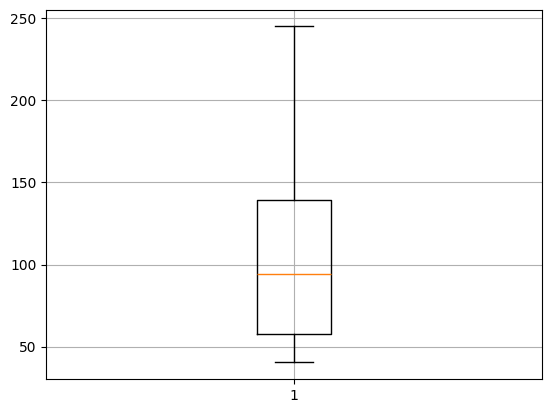

In [43]:
from re import X
plt.boxplot(df['Open'])

plt.grid(['1', '2'])
plt.grid(True)
plt.legend(labels)
plt.show()
plt.show()





